In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
import numpy as np


from pansharpening import PANDataset
from alg3 import PANTVGradAlignement
from torchvision import transforms
from math import sqrt
from nabla import nabla

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
#Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256

    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [3]:
val_transform = transforms.Compose([transforms.CenterCrop(crop_size)]) # Transforms a the input data to torch tensors
dataset = PANDataset(root_dir=data_path, split='train' ,transform=val_transform,normalize= True,scale=2,sigma=0.1,device='cpu', size=crop_size)

In [32]:
idx = 0
X = dataset[idx]
X = X.unsqueeze(0)

In [33]:
 #Matrice de transformation
Y_H = dataset.simulate_low_res_hsi(X)  
Y_M = dataset.get_panchromatic(X)

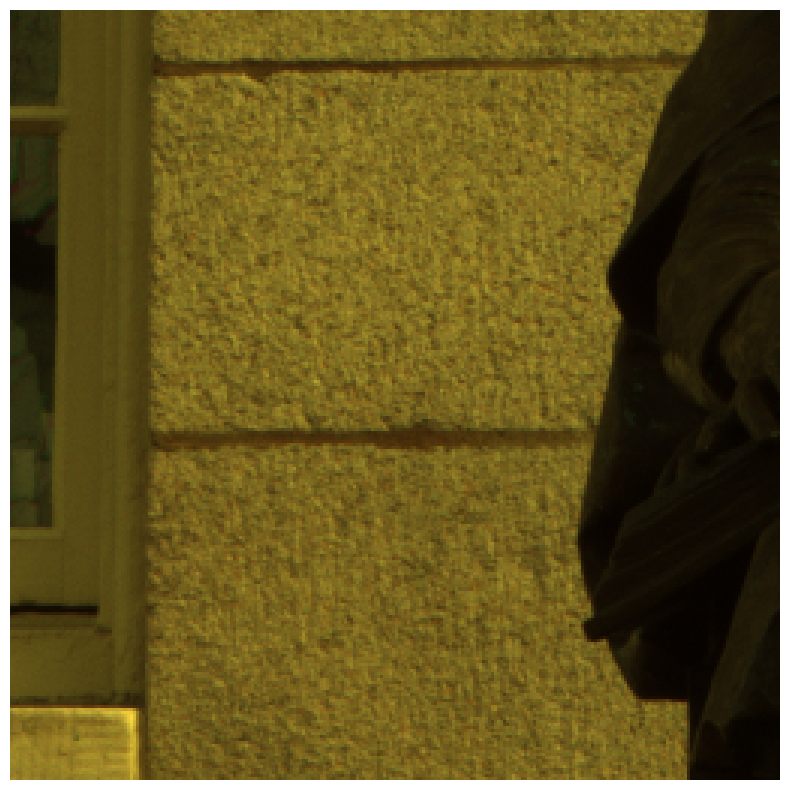

In [39]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')
plt.show()

In [40]:
grad_panc = nabla(Y_M)

In [ ]:
c = threshold(grad_panc)

tensor(0.2606)

In [41]:
norms = torch.norm(grad_panc,dim=-1).cpu().numpy().flatten()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


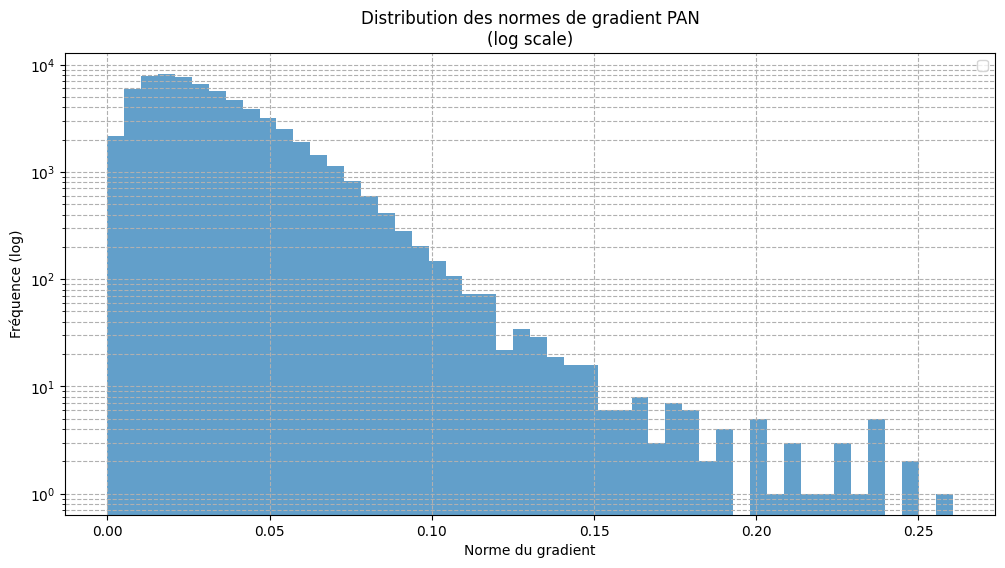

In [43]:
n_bins = 50
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(norms, bins=n_bins, log=True, alpha=0.7)
plt.title('Distribution des normes de gradient PAN\n(log scale)')
plt.xlabel('Norme du gradient')
plt.ylabel('Fréquence (log)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [44]:
import torch
import matplotlib.pyplot as plt

def plot_normalized_gradient_hist(Y_PAN):
    """
    Y_PAN: Image panchromatique [1,1,h,w]
    """
    # 1. Calcul du gradient
    
    grad_P = nabla(Y_PAN)       # [1,1,h,w,2]
    
    # 2. Calcul des normes
    norm_P = torch.norm(grad_P, dim=-1)        # [1,1,h,w]
    total_norm = norm_P.sum()                  # Somme totale
    norm_P_normalized = (norm_P / total_norm).flatten()  # Normalisation
    norm_P_filtered = norm_P_normalized
    
    # 4. Plot histogramme
    plt.figure(figsize=(10,6))
    plt.hist(norm_P_filtered.cpu().numpy(), bins=50, log=True, alpha=0.7)
    plt.title('Distribution des normes de gradient PAN normalisées\n(échelle log)')
    plt.xlabel('Norme normalisée par la somme totale')
    plt.ylabel('Fréquence (log)')
    plt.grid(True, which="both", ls="--")
    
    # 5. Ajout des percentiles clés
    percentiles = [5, 25, 50, 75, 95]
    colors = ['r', 'g', 'b', 'm', 'y']
    
    for p, color in zip(percentiles, colors):
        val = torch.quantile(norm_P_filtered, p/100)
        plt.axvline(val, color=color, linestyle='--', 
                   label=f'{p}%: {val:.2e}')
    
    plt.legend()
    plt.show()

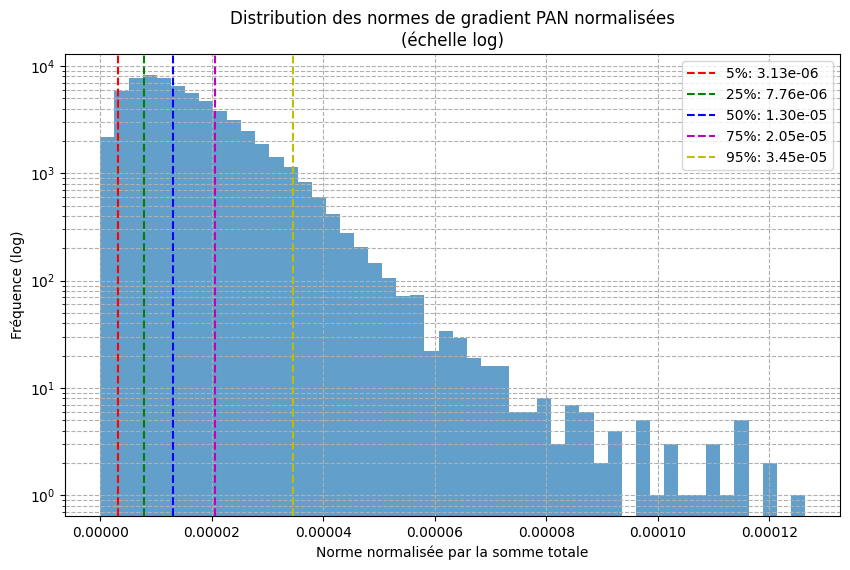

In [38]:
plot_normalized_gradient_hist(Y_M)